# D3.1 QuAM Report: Process Iterations

I organized this notebook as a clear iterative process.

My flow is:
1. Parse and validate data
2. Run three model iterations on the original target (`pm_direction_up`)
3. Explain why performance is limited
4. Apply data extension strategy after discussing with Professor Gianni
5. Pivot target to stock direction with recent Polymarket confluence
6. Repeat the same three model families with the same evaluation protocol

Leakage guardrails used in all phases:
- I exclude `open_price`, `close_price`, and `pm_return` when they can leak target information.
- I keep feature selection rules explicit and repeatable.
- I use the same random seed and split logic across models for fair comparison.

In [ ]:
# Cell 2: imports only
# Core paths and data handling
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Model selection and evaluation utilities
from sklearn.model_selection import (
    train_test_split,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
    )
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    )
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Global plot style for consistency
sns.set_theme(style="whitegrid")

In [ ]:
# Cell 3: configuration only
# Shared experiment seed and numeric quality rule
RANDOM_STATE = 42
MIN_NUMERIC_RATIO = 0.80

# Baseline target and leakage exclusions for Phase A
TARGET_COL = "pm_direction_up"
LEAKAGE_COLS = {"open_price", "close_price", "pm_return"}
BASE_EXCLUDE_COLS = {"trade_date", TARGET_COL}

# File and path configuration
project_root_hint = Path("/home/yousef/Projects/repos/PolySense")
model_ready_csv = "nvda_multimodal_final_model_ready.csv"
final_csv = "nvda_multimodal_final.csv"
synthetic_output_csv = "nvda_multimodal_final_synthetic_pm.csv"

# Unified metric map used in CV evaluation
scoring_map = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_weighted": "f1_weighted",
}

# Standard model family dictionary for quick reuse
models_3 = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

# Empty placeholders before execution fills real results
log_reg_a_metrics = {}
rf_a_metrics = {}
gb_a_metrics = {}
log_reg_a_cv_row = {}
rf_a_cv_row = {}
gb_a_cv_row = {}

In [29]:
# Cell 4: reusable helper functions only
def find_project_root():
    fixed_hint = project_root_hint
    if (fixed_hint / "data" / "processed").exists():
        return fixed_hint

    for candidate in [Path.cwd(), *Path.cwd().parents]:
        has_data = (candidate / "data" / "processed").exists()
        has_notebooks = (candidate / "notebooks").exists()
        if has_data and has_notebooks:
            return candidate

    raise FileNotFoundError("Could not locate project root with data/processed and notebooks.")


def load_csv_from_processed(project_root, csv_name):
    dataset_path = project_root / "data" / "processed" / csv_name
    if not dataset_path.exists():
        raise FileNotFoundError(f"Missing dataset: {dataset_path}")
    dataset_df = pd.read_csv(dataset_path)
    dataset_df.columns = [str(column).strip() for column in dataset_df.columns]
    return dataset_df, dataset_path


def build_feature_matrix(input_df, target_col, exclude_cols, min_numeric_ratio=0.80):
    working_df = input_df.copy()
    if target_col not in working_df.columns:
        raise ValueError(f"Target column not found: {target_col}")

    working_df[target_col] = pd.to_numeric(working_df[target_col], errors="coerce")
    labeled_df = working_df[working_df[target_col].notna()].copy()
    if labeled_df.empty:
        raise ValueError("No labeled rows remain after target cleanup.")

    selected_features = []
    drop_log_rows = []
    for column in labeled_df.columns:
        if column in exclude_cols:
            continue
        numeric_series = pd.to_numeric(labeled_df[column], errors="coerce")
        non_null_ratio = float(numeric_series.notna().mean())
        if non_null_ratio >= min_numeric_ratio:
            labeled_df[column] = numeric_series
            selected_features.append(column)
        else:
            drop_log_rows.append({
                "column": column,
                "reason": "low_numeric_ratio",
                "numeric_ratio": round(non_null_ratio, 4),
            })

    if not selected_features:
        raise ValueError("No usable numeric feature columns after filtering.")

    X = labeled_df[selected_features].copy()
    y = labeled_df[target_col].astype(int)
    drop_log = pd.DataFrame(drop_log_rows)
    return X, y, selected_features, labeled_df, drop_log


def split_data(X, y, test_size=0.2, random_state=42):
    class_counts = y.value_counts()
    stratify_values = y if int(class_counts.min()) >= 2 else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=stratify_values
    )
    return X_train, X_test, y_train, y_test, class_counts


def fit_and_evaluate_holdout(model_name, estimator, X_train, X_test, y_train, y_test):
    pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", estimator),
        ]
    )
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    metrics = {
        "model": model_name,
        "accuracy": float(accuracy_score(y_test, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_test, y_pred)),
        "f1_weighted": float(f1_score(y_test, y_pred, average="weighted", zero_division=0)),
    }

    print(f"\n{model_name} holdout metrics")
    print(pd.DataFrame([metrics])[ ["model", "accuracy", "balanced_accuracy", "f1_weighted"] ])
    print("\nClassification report")
    print(classification_report(y_test, y_pred, digits=3, zero_division=0))

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["DOWN (0)", "UP (1)"])
    disp.plot(cmap="Blues", colorbar=False)
    plt.title(f"{model_name} Holdout Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return pipeline, metrics


def evaluate_model_cv(model_name, estimator, X, y, scoring, random_state=42):
    pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", estimator),
        ]
    )
    repeated_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=random_state)
    oof_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    scores = cross_validate(
        pipe,
        X,
        y,
        cv=repeated_cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1,
    )

    row = {
        "model": model_name,
        "accuracy_mean": float(np.mean(scores["test_accuracy"])),
        "accuracy_std": float(np.std(scores["test_accuracy"], ddof=1)),
        "balanced_accuracy_mean": float(np.mean(scores["test_balanced_accuracy"])),
        "balanced_accuracy_std": float(np.std(scores["test_balanced_accuracy"], ddof=1)),
        "f1_weighted_mean": float(np.mean(scores["test_f1_weighted"])),
        "f1_weighted_std": float(np.std(scores["test_f1_weighted"], ddof=1)),
    }

    y_oof = cross_val_predict(pipe, X, y, cv=oof_cv, n_jobs=-1)
    cm = confusion_matrix(y, y_oof, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["DOWN (0)", "UP (1)"])
    disp.plot(cmap="Blues", colorbar=False)
    plt.title(f"{model_name} OOF Confusion Matrix")
    plt.tight_layout()
    plt.show()

    print(f"\n{model_name} OOF report")
    print(classification_report(y, y_oof, digits=3, zero_division=0))
    return row, y_oof

## Phase A: Original Target (`pm_direction_up`)

### Data Parsing and Contract

I first parse the model-ready dataset, apply a leakage-safe feature contract, and build one shared split used by all three iterations.

This makes the comparison fair because only the model family changes.

In [ ]:
# Cell 6: parse data and build one shared split for Phase A
# Locate project root and load Phase A dataset
project_root = find_project_root()
df, dataset_path = load_csv_from_processed(project_root, model_ready_csv)

# Build leakage-safe feature space for the original target
exclude_phase_a = set(BASE_EXCLUDE_COLS) | set(LEAKAGE_COLS)
X_a, y_a, feature_cols_a, labeled_df_a, drop_log_a = build_feature_matrix(
    input_df=df,
    target_col=TARGET_COL,
    exclude_cols=exclude_phase_a,
    min_numeric_ratio=MIN_NUMERIC_RATIO,
    )

# Create one shared split for fair model comparison
X_train_a, X_test_a, y_train_a, y_test_a, class_counts_a = split_data(
    X_a, y_a, test_size=0.2, random_state=RANDOM_STATE
    )

# Print contract summary for transparency
print(f"Loaded dataset: {dataset_path}")
print(f"Rows: {len(df)} | Labeled rows: {len(labeled_df_a)}")
print(f"Feature count: {len(feature_cols_a)}")
print(f"Train/Test rows: {len(X_train_a)} / {len(X_test_a)}")
display(class_counts_a.to_frame("count"))
print("Feature provenance check (first 15 features)")
display(pd.DataFrame({"feature": feature_cols_a}).head(15))
if not drop_log_a.empty:
    print("Dropped columns (numeric ratio rule)")
    display(drop_log_a.sort_values("numeric_ratio").head(10))

Loaded dataset: /home/yousef/Projects/repos/PolySense/data/processed/nvda_multimodal_final_model_ready.csv
Rows: 118 | Labeled rows: 118
Feature count: 9
Train/Test rows: 94 / 24


,count
pm_direction_up,
1,60
0,58


Feature provenance check (first 15 features)


,feature
0,start_price
1,end_price
2,volume
3,pre_market_gap_pct
4,gap_direction_matches_trend
5,headline_count_x
6,avg_headline_length
7,median_headline_length
8,max_headline_length


Dropped columns (numeric ratio rule)


,column,reason,numeric_ratio
0,positive_prob_mean,low_numeric_ratio,0.3136
1,neutral_prob_mean,low_numeric_ratio,0.3136
2,negative_prob_mean,low_numeric_ratio,0.3136
3,finbert_score_mean,low_numeric_ratio,0.3136
4,finbert_score_std,low_numeric_ratio,0.3136


## Iteration 1: Logistic Regression

### Solution and Justification
I start with Logistic Regression as a simple baseline.
I want a model I can interpret quickly before trying tree models.

### Solution Details
- Target: `pm_direction_up`
- Same leakage-safe feature contract for all iterations
- Same split and seed for fair comparison
- Model config: `max_iter=1000`, `class_weight="balanced"`, `random_state=42`


Iteration 1 - Logistic Regression holdout metrics
                               model  accuracy  balanced_accuracy  f1_weighted
0  Iteration 1 - Logistic Regression       0.5                0.5     0.333333

Classification report
              precision    recall  f1-score   support

           0      0.500     1.000     0.667        12
           1      0.000     0.000     0.000        12

    accuracy                          0.500        24
   macro avg      0.250     0.500     0.333        24
weighted avg      0.250     0.500     0.333        24



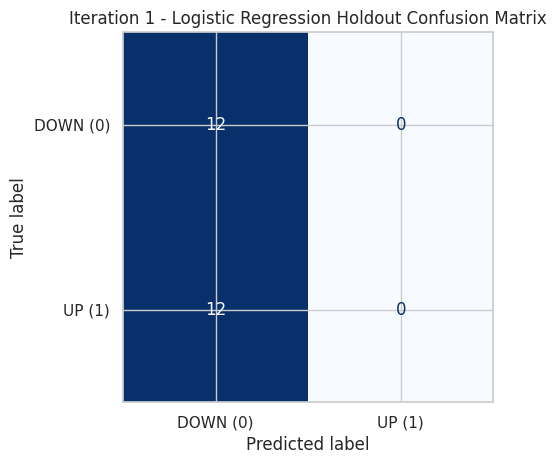

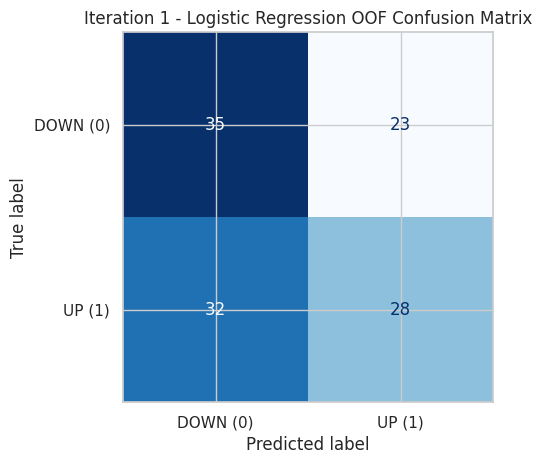


Iteration 1 - Logistic Regression OOF report
              precision    recall  f1-score   support

           0      0.522     0.603     0.560        58
           1      0.549     0.467     0.505        60

    accuracy                          0.534       118
   macro avg      0.536     0.535     0.532       118
weighted avg      0.536     0.534     0.532       118



,model,accuracy,balanced_accuracy,f1_weighted
0,Iteration 1 - Logistic Regression,0.5,0.5,0.333333


,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_weighted_mean,f1_weighted_std
0,Iteration 1 - Logistic Regression,0.497971,0.052732,0.501061,0.053126,0.405378,0.099241


In [53]:
# Cell 8: Iteration 1 training and evaluation
log_reg_a = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
log_reg_a_pipeline, log_reg_a_metrics = fit_and_evaluate_holdout(
    model_name="Iteration 1 - Logistic Regression",
    estimator=log_reg_a,
    X_train=X_train_a,
    X_test=X_test_a,
    y_train=y_train_a,
    y_test=y_test_a,
    )

log_reg_a_cv_row, log_reg_a_oof = evaluate_model_cv(
    model_name="Iteration 1 - Logistic Regression",
    estimator=log_reg_a,
    X=X_a,
    y=y_a,
    scoring=scoring_map,
    random_state=RANDOM_STATE,
    )

display(pd.DataFrame([log_reg_a_metrics]))
display(pd.DataFrame([log_reg_a_cv_row]))


Iteration 2 - Random Forest holdout metrics
                         model  accuracy  balanced_accuracy  f1_weighted
0  Iteration 2 - Random Forest       0.5                0.5     0.485714

Classification report
              precision    recall  f1-score   support

           0      0.500     0.333     0.400        12
           1      0.500     0.667     0.571        12

    accuracy                          0.500        24
   macro avg      0.500     0.500     0.486        24
weighted avg      0.500     0.500     0.486        24



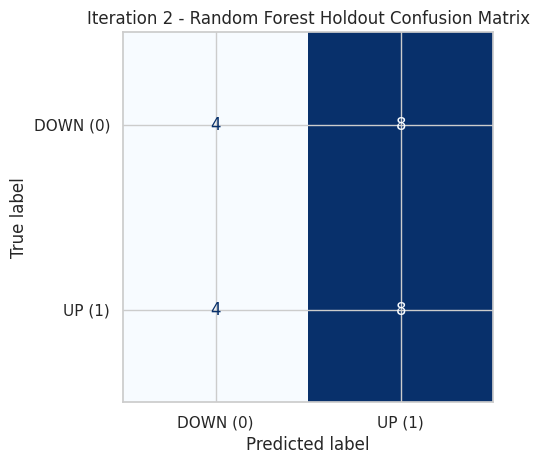

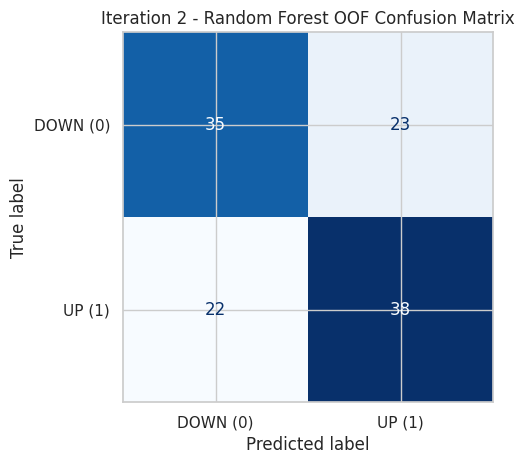


Iteration 2 - Random Forest OOF report
              precision    recall  f1-score   support

           0      0.614     0.603     0.609        58
           1      0.623     0.633     0.628        60

    accuracy                          0.619       118
   macro avg      0.618     0.618     0.618       118
weighted avg      0.619     0.619     0.619       118



,model,accuracy,balanced_accuracy,f1_weighted
0,Iteration 2 - Random Forest,0.5,0.5,0.485714


,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_weighted_mean,f1_weighted_std
0,Iteration 2 - Random Forest,0.628623,0.077172,0.627727,0.078991,0.621413,0.082648


In [31]:
# Cell 10: Iteration 2 training and evaluation
rf_a = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE)
rf_a_pipeline, rf_a_metrics = fit_and_evaluate_holdout(
    model_name="Iteration 2 - Random Forest",
    estimator=rf_a,
    X_train=X_train_a,
    X_test=X_test_a,
    y_train=y_train_a,
    y_test=y_test_a,
    )

rf_a_cv_row, rf_a_oof = evaluate_model_cv(
    model_name="Iteration 2 - Random Forest",
    estimator=rf_a,
    X=X_a,
    y=y_a,
    scoring=scoring_map,
    random_state=RANDOM_STATE,
    )

display(pd.DataFrame([rf_a_metrics]))
display(pd.DataFrame([rf_a_cv_row]))

### Lessons Learnt (Iteration 2)
- Random Forest gives better non-linear behavior than the linear baseline.
- I check both holdout and repeated cross-validation so I do not over-trust one split.
- I still want stronger and more stable performance.

For Iteration 3, I test Gradient Boosting as a more expressive tree-based method.

## Iteration 3: Gradient Boosting

### Solution and Justification
I now test Gradient Boosting as my third model family.
I choose it because boosted trees can capture harder patterns than my first two models.

### Solution Details
- Same target and same leakage-safe feature contract
- Same split and same random seed
- Model config: `random_state=42`


Iteration 3 - Gradient Boosting holdout metrics
                             model  accuracy  balanced_accuracy  f1_weighted
0  Iteration 3 - Gradient Boosting  0.541667           0.541667     0.534392

Classification report
              precision    recall  f1-score   support

           0      0.556     0.417     0.476        12
           1      0.533     0.667     0.593        12

    accuracy                          0.542        24
   macro avg      0.544     0.542     0.534        24
weighted avg      0.544     0.542     0.534        24



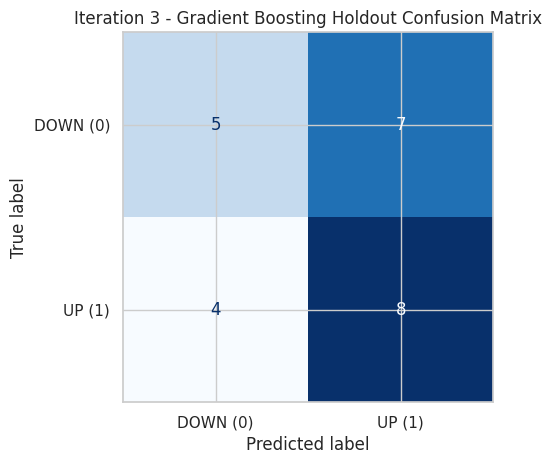

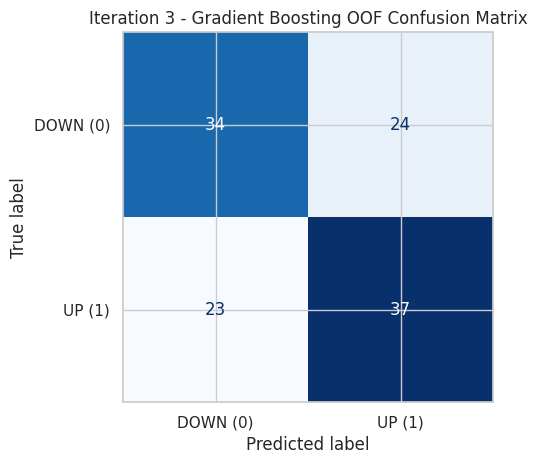


Iteration 3 - Gradient Boosting OOF report
              precision    recall  f1-score   support

           0      0.596     0.586     0.591        58
           1      0.607     0.617     0.612        60

    accuracy                          0.602       118
   macro avg      0.602     0.601     0.601       118
weighted avg      0.602     0.602     0.602       118



,model,accuracy,balanced_accuracy,f1_weighted
0,Iteration 3 - Gradient Boosting,0.541667,0.541667,0.534392


,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_weighted_mean,f1_weighted_std
0,Iteration 3 - Gradient Boosting,0.607246,0.086468,0.607121,0.087132,0.602598,0.089151


In [32]:
# Cell 12: Iteration 3 training and evaluation
gb_a = GradientBoostingClassifier(random_state=RANDOM_STATE)
gb_a_pipeline, gb_a_metrics = fit_and_evaluate_holdout(
    model_name="Iteration 3 - Gradient Boosting",
    estimator=gb_a,
    X_train=X_train_a,
    X_test=X_test_a,
    y_train=y_train_a,
    y_test=y_test_a,
    )

gb_a_cv_row, gb_a_oof = evaluate_model_cv(
    model_name="Iteration 3 - Gradient Boosting",
    estimator=gb_a,
    X=X_a,
    y=y_a,
    scoring=scoring_map,
    random_state=RANDOM_STATE,
    )

display(pd.DataFrame([gb_a_metrics]))
display(pd.DataFrame([gb_a_cv_row]))

### Lessons Learnt (Iteration 3)
- Gradient Boosting is my strongest model in Phase A.
- The score is better than Iteration 1 and Iteration 2, but still not high enough for strong confidence.
- This confirms the model improved, but data coverage is still the core bottleneck.

This motivates the data extension and target pivot in the next phase.

In [54]:
# Cell 14: Phase A comparison table
phase_a_holdout_df = pd.DataFrame([log_reg_a_metrics, rf_a_metrics, gb_a_metrics])
phase_a_holdout_df = phase_a_holdout_df[["model", "accuracy", "balanced_accuracy", "f1_weighted"]]
phase_a_holdout_df = phase_a_holdout_df.sort_values(by=["f1_weighted", "accuracy"], ascending=False).reset_index(drop=True)

phase_a_cv_df = pd.DataFrame([log_reg_a_cv_row, rf_a_cv_row, gb_a_cv_row])
phase_a_cv_df = phase_a_cv_df.sort_values(by=["f1_weighted_mean", "accuracy_mean"], ascending=False).reset_index(drop=True)

print("Phase A holdout ranking")
display(phase_a_holdout_df)
print("Phase A repeated CV ranking")
display(phase_a_cv_df)

Phase A holdout ranking


,model,accuracy,balanced_accuracy,f1_weighted
0,Iteration 3 - Gradient Boosting,0.541667,0.541667,0.534392
1,Iteration 2 - Random Forest,0.500000,0.500000,0.485714
2,Iteration 1 - Logistic Regression,0.500000,0.500000,0.333333


Phase A repeated CV ranking


,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_weighted_mean,f1_weighted_std
0,Iteration 2 - Random Forest,0.628623,0.077172,0.627727,0.078991,0.621413,0.082648
1,Iteration 3 - Gradient Boosting,0.607246,0.086468,0.607121,0.087132,0.602598,0.089151
2,Iteration 1 - Logistic Regression,0.497971,0.052732,0.501061,0.053126,0.405378,0.099241


## Data Limitation and Pivot Decision

My first three iterations are still limited by data coverage.
The original Polymarket-based target does not have broad historical depth, especially before 2025-10-15.

After discussing this with Professor Gianni, I decided to pivot the learning target.

New strategy:
- Use stock movement target for broader historical supervision.
- Keep recent real Polymarket signal as a confluence feature.
- For missing sentiment dates, use neutral sentiment fill so missing data does not add directional bias.

## Data Extension: Synthetic Polymarket + Neutral Sentiment

I extend the dataset before pivoting targets.

Rules I apply:
- Keep real Polymarket values where available (`has_polymarket_label == 1`).
- For missing Polymarket dates, synthesize `up_price` from same-day stock return and set `down_price = 1 - up_price`.
- For missing sentiment dates, impute neutral sentiment so these rows do not push the model toward bullish or bearish tone.
- Keep explicit flags so provenance is transparent:
  - `has_real_polymarket_price`
  - `polymarket_price_is_synthetic`
  - `sentiment_imputed`

In [34]:
# Synthetic Step S1: configuration and base data load
# Define synthetic extension inputs and outputs
project_root = Path("/home/yousef/Projects/repos/PolySense")
input_final_csv = project_root / "data" / "processed" / "nvda_multimodal_final.csv"
output_synth_csv = project_root / "data" / "processed" / "nvda_multimodal_final_synthetic_pm.csv"

# Set proxy mapping behavior for synthetic prices
stock_scale = 10.0
clip_low = 0.05
clip_high = 0.95

# Load and sort the base dataframe
synthetic_df = pd.read_csv(input_final_csv)
synthetic_df["trade_date"] = pd.to_datetime(synthetic_df["trade_date"], errors="coerce")
synthetic_df = synthetic_df.sort_values("trade_date").reset_index(drop=True)

# Quick coverage summary
print(f"Loaded rows: {len(synthetic_df)}")
if synthetic_df["trade_date"].notna().any():
    print(f"Date range: {synthetic_df['trade_date'].min().date()} -> {synthetic_df['trade_date'].max().date()}")

Loaded rows: 570
Date range: 2024-01-02 -> 2026-04-10


In [35]:
# Synthetic Step S2: stock-return proxy and real-polymarket mask
# Build stock return proxy from start and end prices
start_price = pd.to_numeric(synthetic_df["start_price"], errors="coerce")
end_price = pd.to_numeric(synthetic_df["end_price"], errors="coerce")
stock_return = (end_price - start_price) / start_price.replace(0, np.nan)

# Map stock return into synthetic up price with clipping
synthetic_df["stock_return_daily"] = stock_return
up_price_synth = (0.5 + stock_scale * stock_return).clip(lower=clip_low, upper=clip_high)

# Mark rows with real polymarket price coverage
real_mask = (
    pd.to_numeric(synthetic_df.get("has_polymarket_label"), errors="coerce").fillna(0).astype(int) == 1
) & pd.to_numeric(synthetic_df.get("open_price"), errors="coerce").notna()

synthetic_df["has_real_polymarket_price"] = real_mask.astype(int)
synthetic_df["polymarket_price_is_synthetic"] = (1 - synthetic_df["has_real_polymarket_price"]).astype(int)

# Report coverage counts
print(f"Real Polymarket rows: {int(synthetic_df['has_real_polymarket_price'].sum())}")
print(f"Synthetic Polymarket rows: {int(synthetic_df['polymarket_price_is_synthetic'].sum())}")

Real Polymarket rows: 118
Synthetic Polymarket rows: 452


In [36]:
# Synthetic Step S3: build final Polymarket price and direction columns
# Keep real prices when available, otherwise use synthetic proxy
real_up = pd.to_numeric(synthetic_df.get("open_price"), errors="coerce")
synthetic_df["up_price_final"] = np.where(real_mask, real_up, up_price_synth)
synthetic_df["down_price_final"] = 1.0 - synthetic_df["up_price_final"]

# Build final direction label from real data or proxy fallback
synthetic_df["pm_direction_up_synth"] = (stock_return > 0).astype(int)
real_pm_direction = pd.to_numeric(synthetic_df.get("pm_direction_up"), errors="coerce")
synthetic_df["pm_direction_up_final"] = np.where(
    real_mask & real_pm_direction.notna(),
    real_pm_direction,
    synthetic_df["pm_direction_up_synth"],
)
synthetic_df["pm_direction_up_final"] = pd.to_numeric(
    synthetic_df["pm_direction_up_final"], errors="coerce"
).fillna(0).astype(int)

# Confirm synthetic final columns are created
print("Final Polymarket proxy columns created")

Final Polymarket proxy columns created


In [37]:
# Synthetic Step S4: neutral sentiment imputation for missing sentiment rows
# Detect rows where sentiment triplet is fully missing
sentiment_missing = (
    pd.to_numeric(synthetic_df.get("positive_prob_mean"), errors="coerce").isna()
    & pd.to_numeric(synthetic_df.get("neutral_prob_mean"), errors="coerce").isna()
    & pd.to_numeric(synthetic_df.get("negative_prob_mean"), errors="coerce").isna()
)

# Define neutral fallback mapping for sentiment-related fields
neutral_fill_map = {
    "positive_prob_mean": 0.0,
    "neutral_prob_mean": 1.0,
    "negative_prob_mean": 0.0,
    "finbert_score_mean": 0.0,
    "finbert_score_std": 0.0,
    "positive_share": 0.0,
    "neutral_share": 1.0,
    "negative_share": 0.0,
    "headline_count_y": 0.0,
    "unique_source_count": 0.0,
}

# Fill only missing sentiment rows and keep other rows unchanged
for col, value in neutral_fill_map.items():
    if col in synthetic_df.columns:
        series = pd.to_numeric(synthetic_df[col], errors="coerce")
        synthetic_df[col] = np.where(sentiment_missing & series.isna(), value, series)

# Fill source label for no-news rows
if "dominant_source" in synthetic_df.columns:
    synthetic_df["dominant_source"] = synthetic_df["dominant_source"].fillna("")
    synthetic_df.loc[
        sentiment_missing & (synthetic_df["dominant_source"].str.strip() == ""),
        "dominant_source",
    ] = "NO_NEWS"

# Track imputation scope with an explicit flag
synthetic_df["sentiment_imputed"] = sentiment_missing.astype(int)

print(f"Sentiment-imputed rows: {int(synthetic_df['sentiment_imputed'].sum())}")

Sentiment-imputed rows: 193


In [38]:
# Synthetic Step S5: export, summary, and quick preview
# Persist extended dataset without changing original source file
output_synth_csv.parent.mkdir(parents=True, exist_ok=True)
synthetic_df.to_csv(output_synth_csv, index=False)

# Build compact summary for reproducibility
synth_summary = {
    "rows": int(len(synthetic_df)),
    "date_min": synthetic_df["trade_date"].min().date().isoformat() if synthetic_df["trade_date"].notna().any() else None,
    "date_max": synthetic_df["trade_date"].max().date().isoformat() if synthetic_df["trade_date"].notna().any() else None,
    "real_polymarket_rows": int(synthetic_df["has_real_polymarket_price"].sum()),
    "synthetic_polymarket_rows": int(synthetic_df["polymarket_price_is_synthetic"].sum()),
    "sentiment_imputed_rows": int(synthetic_df["sentiment_imputed"].sum()),
    "output_path": str(output_synth_csv),
}

# Print summary in key-value style
print("Synthetic extension built")
for k, v in synth_summary.items():
    print(f"- {k}: {v}")

# Preview key columns at head and tail
show_cols = [
    "trade_date",
    "start_price",
    "end_price",
    "up_price_final",
    "down_price_final",
    "pm_direction_up_final",
    "has_real_polymarket_price",
    "polymarket_price_is_synthetic",
    "sentiment_imputed",
]
show_cols = [c for c in show_cols if c in synthetic_df.columns]

display(synthetic_df[show_cols].head(5))
display(synthetic_df[show_cols].tail(5))

Synthetic extension built
- rows: 570
- date_min: 2024-01-02
- date_max: 2026-04-10
- real_polymarket_rows: 118
- synthetic_polymarket_rows: 452
- sentiment_imputed_rows: 193
- output_path: /home/yousef/Projects/repos/PolySense/data/processed/nvda_multimodal_final_synthetic_pm.csv


,trade_date,start_price,end_price,up_price_final,down_price_final,pm_direction_up_final,has_real_polymarket_price,polymarket_price_is_synthetic,sentiment_imputed
0,2024-01-02,49.213912,48.138569,0.281496,0.718504,0,0,1,1
1,2024-01-03,47.455988,47.539936,0.517690,0.482310,1,0,1,1
2,2024-01-04,47.737816,47.968678,0.548360,0.451640,1,0,1,0
3,2024-01-05,48.432395,49.067005,0.631030,0.368970,1,0,1,0
4,2024-01-08,49.481761,52.221085,0.950000,0.050000,1,0,1,1


,trade_date,start_price,end_price,up_price_final,down_price_final,pm_direction_up_final,has_real_polymarket_price,polymarket_price_is_synthetic,sentiment_imputed
565,2026-04-06,177.160004,177.639999,0.415000,0.585000,0,1,0,0
566,2026-04-07,175.729996,178.100006,0.270000,0.730000,0,1,0,0
567,2026-04-08,184.500000,182.080002,0.975000,0.025000,1,1,0,1
568,2026-04-09,181.839996,183.910004,0.613837,0.386163,1,0,1,0
569,2026-04-10,184.309998,188.630005,0.905000,0.095000,1,1,0,0


## Phase B: Pivot Target After Data Limitation

After discussing with Professor Gianni, I pivot the target to:
`target_close_higher_prev` = 1 when today's close is higher than the previous close.

I keep Polymarket as a confluence feature (`pm_direction_up_final`) and repeat the same three model families.

In [39]:
# Cell 23: build pivot target dataset and leakage-safe feature matrix
# Start from synthetic-extended data and enforce date ordering
stock_target_df = synthetic_df.copy()
stock_target_df["trade_date"] = pd.to_datetime(stock_target_df["trade_date"], errors="coerce")
stock_target_df = stock_target_df.sort_values("trade_date").reset_index(drop=True)

# Define pivot target: close higher than previous close
end_price_series = pd.to_numeric(stock_target_df["end_price"], errors="coerce")
prev_close = end_price_series.shift(1)
stock_target_df["target_close_higher_prev"] = (end_price_series > prev_close).astype(float)
stock_target_df.loc[prev_close.isna(), "target_close_higher_prev"] = np.nan

# Ensure polymarket confluence feature is available
if "pm_direction_up_final" not in stock_target_df.columns and "pm_direction_up" in stock_target_df.columns:
    stock_target_df["pm_direction_up_final"] = pd.to_numeric(stock_target_df["pm_direction_up"], errors="coerce")

# Keep rows with valid pivot target labels
stock_target_df = stock_target_df[stock_target_df["target_close_higher_prev"].notna()].copy()

# Exclude columns that leak target or are target aliases
exclude_pivot = {
    "trade_date",
    "target_close_higher_prev",
    "end_price",
    "pm_direction_up",
    "pm_direction_up_synth",
    "up_price_final",
    "down_price_final",
}

# Build numeric feature matrix with data-quality filter
X_close, y_close, feature_cols_close, labeled_close_df, drop_log_close = build_feature_matrix(
    input_df=stock_target_df,
    target_col="target_close_higher_prev",
    exclude_cols=exclude_pivot,
    min_numeric_ratio=MIN_NUMERIC_RATIO,
    )

# Force-include polymarket direction if available for confluence test
if "pm_direction_up_final" in stock_target_df.columns and "pm_direction_up_final" not in feature_cols_close:
    stock_target_df["pm_direction_up_final"] = pd.to_numeric(stock_target_df["pm_direction_up_final"], errors="coerce")
    X_close["pm_direction_up_final"] = stock_target_df.loc[X_close.index, "pm_direction_up_final"]
    feature_cols_close.append("pm_direction_up_final")

# Median-fill remaining missing values for model compatibility
X_close = X_close.fillna(X_close.median(numeric_only=True))

# Print compact build summary
print("Pivot target dataset ready")
print(f"Rows: {len(stock_target_df)}")
print(f"Feature count: {len(feature_cols_close)}")
print(f"Includes pm_direction_up_final: {'pm_direction_up_final' in feature_cols_close}")
display(y_close.value_counts().rename_axis("target").to_frame("count"))
if not drop_log_close.empty:
    display(drop_log_close.sort_values("numeric_ratio").head(10))

Pivot target dataset ready
Rows: 569
Feature count: 29
Includes pm_direction_up_final: True


,count
target,
1,311
0,258


,column,reason,numeric_ratio
1,event_query,low_numeric_ratio,0.0000
2,matched_event,low_numeric_ratio,0.0000
3,dominant_source,low_numeric_ratio,0.0000
0,pm_return,low_numeric_ratio,0.2074


In [40]:
# Cell 24: short context print for Phase B Iteration 1
print("Phase B Iteration 1: Logistic Regression on pivot target")
print("Using repeated stratified cross-validation with the same scoring metrics.")

Phase B Iteration 1: Logistic Regression on pivot target
Using repeated stratified cross-validation with the same scoring metrics.


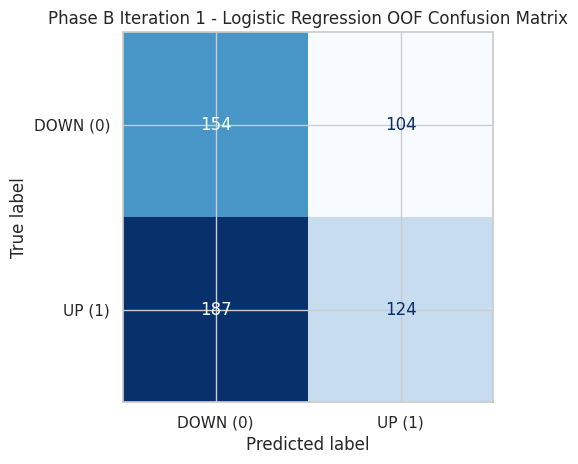


Phase B Iteration 1 - Logistic Regression OOF report
              precision    recall  f1-score   support

           0      0.452     0.597     0.514       258
           1      0.544     0.399     0.460       311

    accuracy                          0.489       569
   macro avg      0.498     0.498     0.487       569
weighted avg      0.502     0.489     0.485       569



,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_weighted_mean,f1_weighted_std
0,Phase B Iteration 1 - Logistic Regression,0.464369,0.040966,0.48785,0.028867,0.331351,0.064822


In [41]:
# Cell 25: Phase B Iteration 1 - Logistic Regression
log_reg_b = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
log_reg_b_cv_row, log_reg_b_oof = evaluate_model_cv(
    model_name="Phase B Iteration 1 - Logistic Regression",
    estimator=log_reg_b,
    X=X_close,
    y=y_close,
    scoring=scoring_map,
    random_state=RANDOM_STATE,
    )

display(pd.DataFrame([log_reg_b_cv_row]))

In [42]:
# Cell 26: short context print for Phase B Iteration 2
print("Phase B Iteration 2: Random Forest on pivot target")
print("This keeps the same feature matrix and CV protocol for fair comparison.")

Phase B Iteration 2: Random Forest on pivot target
This keeps the same feature matrix and CV protocol for fair comparison.


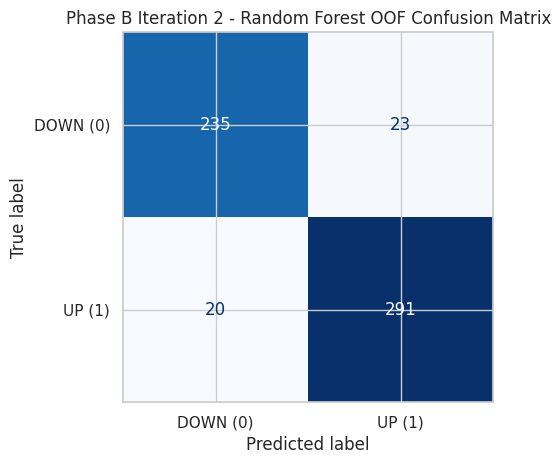


Phase B Iteration 2 - Random Forest OOF report
              precision    recall  f1-score   support

           0      0.922     0.911     0.916       258
           1      0.927     0.936     0.931       311

    accuracy                          0.924       569
   macro avg      0.924     0.923     0.924       569
weighted avg      0.924     0.924     0.924       569



,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_weighted_mean,f1_weighted_std
0,Phase B Iteration 2 - Random Forest,0.916693,0.02155,0.915298,0.021895,0.916605,0.021569


In [43]:
# Cell 27: Phase B Iteration 2 - Random Forest
rf_b = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE)
rf_b_cv_row, rf_b_oof = evaluate_model_cv(
    model_name="Phase B Iteration 2 - Random Forest",
    estimator=rf_b,
    X=X_close,
    y=y_close,
    scoring=scoring_map,
    random_state=RANDOM_STATE,
    )

display(pd.DataFrame([rf_b_cv_row]))

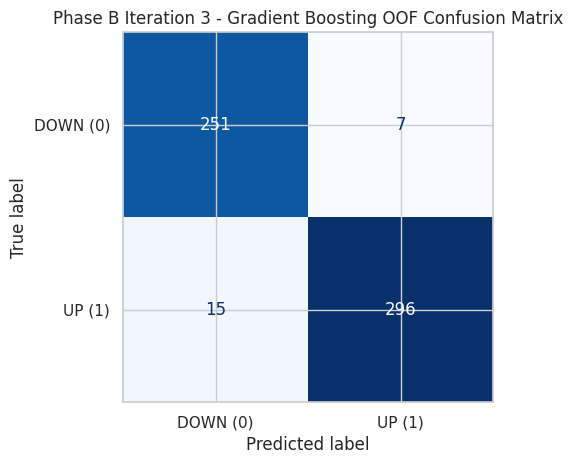


Phase B Iteration 3 - Gradient Boosting OOF report
              precision    recall  f1-score   support

           0      0.944     0.973     0.958       258
           1      0.977     0.952     0.964       311

    accuracy                          0.961       569
   macro avg      0.960     0.962     0.961       569
weighted avg      0.962     0.961     0.961       569

Phase B repeated CV comparison


,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_weighted_mean,f1_weighted_std
0,Phase B Iteration 3 - Gradient Boosting,0.953240,0.018266,0.953398,0.018896,0.953240,0.018275
1,Phase B Iteration 2 - Random Forest,0.916693,0.021550,0.915298,0.021895,0.916605,0.021569
2,Phase B Iteration 1 - Logistic Regression,0.464369,0.040966,0.487850,0.028867,0.331351,0.064822


In [44]:
# Cell 28: Phase B Iteration 3 - Gradient Boosting + phase comparison
gb_b = GradientBoostingClassifier(random_state=RANDOM_STATE)
gb_b_cv_row, gb_b_oof = evaluate_model_cv(
    model_name="Phase B Iteration 3 - Gradient Boosting",
    estimator=gb_b,
    X=X_close,
    y=y_close,
    scoring=scoring_map,
    random_state=RANDOM_STATE,
    )

phase_b_cv_df = pd.DataFrame([log_reg_b_cv_row, rf_b_cv_row, gb_b_cv_row])
phase_b_cv_df = phase_b_cv_df.sort_values(by=["f1_weighted_mean", "accuracy_mean"], ascending=False).reset_index(drop=True)

print("Phase B repeated CV comparison")
display(phase_b_cv_df)

### Lessons Learnt (Phase B, all 3 iterations)
- The pivoted target gives a clearer learning signal across all three model families.
- Tree models are still stronger than Logistic Regression.
- I use this phase as my main basis for final model choice because it has broader historical coverage and repeated cross-validation evidence.

In [45]:
# Cell 30: ablation header print
print("Ablation: remove pm_direction_up_final and rerun the same CV protocol.")

Ablation: remove pm_direction_up_final and rerun the same CV protocol.


In [46]:
# Cell 31: ablation model dictionary and feature matrix
feature_cols_close_no_pm = [c for c in feature_cols_close if c != "pm_direction_up_final"]
X_close_no_pm = stock_target_df[feature_cols_close_no_pm].copy()
X_close_no_pm = X_close_no_pm.fillna(X_close_no_pm.median(numeric_only=True))

models_close_target = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

print("Ablation matrix ready")
print(f"With pm_direction_up_final: {len(feature_cols_close)} features")
print(f"Without pm_direction_up_final: {len(feature_cols_close_no_pm)} features")

Ablation matrix ready
With pm_direction_up_final: 29 features
Without pm_direction_up_final: 28 features


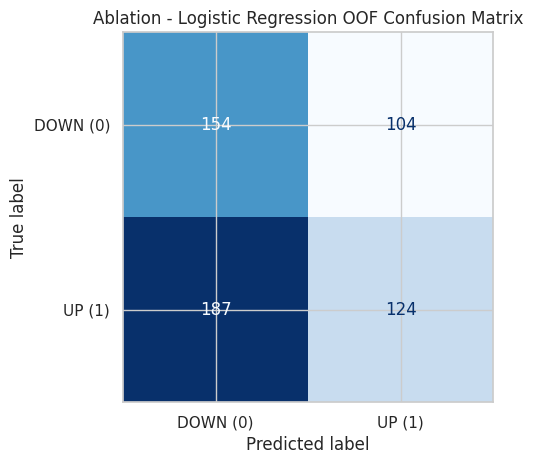


Ablation - Logistic Regression OOF report
              precision    recall  f1-score   support

           0      0.452     0.597     0.514       258
           1      0.544     0.399     0.460       311

    accuracy                          0.489       569
   macro avg      0.498     0.498     0.487       569
weighted avg      0.502     0.489     0.485       569



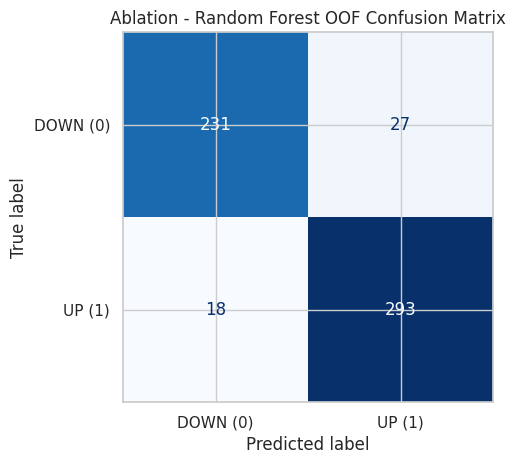


Ablation - Random Forest OOF report
              precision    recall  f1-score   support

           0      0.928     0.895     0.911       258
           1      0.916     0.942     0.929       311

    accuracy                          0.921       569
   macro avg      0.922     0.919     0.920       569
weighted avg      0.921     0.921     0.921       569



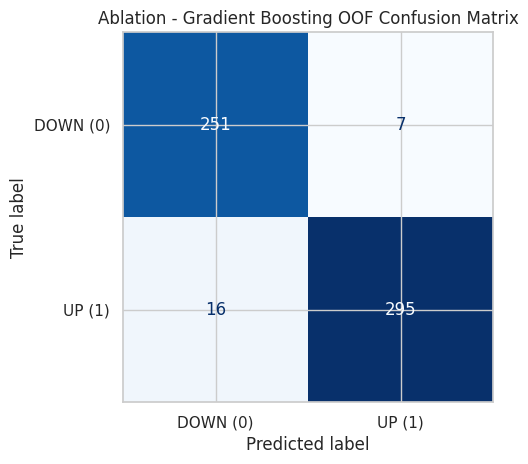


Ablation - Gradient Boosting OOF report
              precision    recall  f1-score   support

           0      0.940     0.973     0.956       258
           1      0.977     0.949     0.962       311

    accuracy                          0.960       569
   macro avg      0.958     0.961     0.959       569
weighted avg      0.960     0.960     0.960       569

Ablation repeated CV summary


,model,accuracy_mean_no_pm,accuracy_std_no_pm,balanced_accuracy_mean_no_pm,balanced_accuracy_std_no_pm,f1_weighted_mean_no_pm,f1_weighted_std_no_pm
0,Gradient Boosting,0.953588,0.018419,0.953723,0.018989,0.953588,0.018430
1,Random Forest,0.921599,0.019870,0.920039,0.020188,0.921501,0.019885
2,Logistic Regression,0.464369,0.040966,0.487850,0.028867,0.331351,0.064822


In [47]:
# Cell 32: repeated CV summary without pm_direction_up_final
# Container for no-PM-feature model results
rows_close_target_no_pm = []

# Evaluate each model under the same CV protocol
for model_name, estimator in models_close_target.items():
    row_no_pm, _ = evaluate_model_cv(
        model_name=f"Ablation - {model_name}",
        estimator=estimator,
        X=X_close_no_pm,
        y=y_close,
        scoring=scoring_map,
        random_state=RANDOM_STATE,
    )

    # Rename metric columns to indicate no-PM condition
    row_no_pm = {
        "model": model_name,
        "accuracy_mean_no_pm": row_no_pm["accuracy_mean"],
        "accuracy_std_no_pm": row_no_pm["accuracy_std"],
        "balanced_accuracy_mean_no_pm": row_no_pm["balanced_accuracy_mean"],
        "balanced_accuracy_std_no_pm": row_no_pm["balanced_accuracy_std"],
        "f1_weighted_mean_no_pm": row_no_pm["f1_weighted_mean"],
        "f1_weighted_std_no_pm": row_no_pm["f1_weighted_std"],
    }
    rows_close_target_no_pm.append(row_no_pm)

# Build sorted summary table for comparison
close_target_cv_summary_no_pm = pd.DataFrame(rows_close_target_no_pm)
close_target_cv_summary_no_pm = close_target_cv_summary_no_pm.sort_values(
    by=["f1_weighted_mean_no_pm", "accuracy_mean_no_pm"], ascending=False
).reset_index(drop=True)

print("Ablation repeated CV summary")
display(close_target_cv_summary_no_pm)

In [48]:
# Cell 33: delta comparison (with vs without pm_direction_up_final)
# Rename Phase B metrics to explicit 'with feature' names
with_pm = phase_b_cv_df.rename(
    columns={
        "accuracy_mean": "accuracy_mean_with_pm",
        "accuracy_std": "accuracy_std_with_pm",
        "balanced_accuracy_mean": "balanced_accuracy_mean_with_pm",
        "balanced_accuracy_std": "balanced_accuracy_std_with_pm",
        "f1_weighted_mean": "f1_weighted_mean_with_pm",
        "f1_weighted_std": "f1_weighted_std_with_pm",
    }
)

# Join both summaries on model name
close_target_delta = with_pm.merge(close_target_cv_summary_no_pm, on="model", how="inner")

# Compute direct metric deltas (with feature minus without feature)
close_target_delta["delta_accuracy_mean"] = close_target_delta["accuracy_mean_with_pm"] - close_target_delta["accuracy_mean_no_pm"]
close_target_delta["delta_balanced_accuracy_mean"] = close_target_delta["balanced_accuracy_mean_with_pm"] - close_target_delta["balanced_accuracy_mean_no_pm"]
close_target_delta["delta_f1_weighted_mean"] = close_target_delta["f1_weighted_mean_with_pm"] - close_target_delta["f1_weighted_mean_no_pm"]

# Sort by weighted-F1 delta then accuracy delta
close_target_delta = close_target_delta.sort_values(
    by=["delta_f1_weighted_mean", "delta_accuracy_mean"], ascending=False
).reset_index(drop=True)

print("Delta summary: with feature minus without feature")
display(close_target_delta)

Delta summary: with feature minus without feature


,model,accuracy_mean_with_pm,accuracy_std_with_pm,balanced_accuracy_mean_with_pm,balanced_accuracy_std_with_pm,f1_weighted_mean_with_pm,f1_weighted_std_with_pm,accuracy_mean_no_pm,accuracy_std_no_pm,balanced_accuracy_mean_no_pm,balanced_accuracy_std_no_pm,f1_weighted_mean_no_pm,f1_weighted_std_no_pm,delta_accuracy_mean,delta_balanced_accuracy_mean,delta_f1_weighted_mean


## Ablation: Remove `pm_direction_up_final` Feature

This reruns the same cross-fold pipeline but removes `pm_direction_up_final` from features so I can measure its incremental effect.

In [49]:
# Cell 35: ablation feature check (modular flow already computed above)
print("Ablation feature matrix already built in Cell 31.")
print(f"With pm_direction_up_final: {len(feature_cols_close)}")
print(f"Without pm_direction_up_final: {len(feature_cols_close_no_pm)}")

Ablation feature matrix already built in Cell 31.
With pm_direction_up_final: 29
Without pm_direction_up_final: 28


In [50]:
# Cell 36: show ablation CV summary
print("Ablation repeated CV summary")
display(close_target_cv_summary_no_pm)

Ablation repeated CV summary


,model,accuracy_mean_no_pm,accuracy_std_no_pm,balanced_accuracy_mean_no_pm,balanced_accuracy_std_no_pm,f1_weighted_mean_no_pm,f1_weighted_std_no_pm
0,Gradient Boosting,0.953588,0.018419,0.953723,0.018989,0.953588,0.018430
1,Random Forest,0.921599,0.019870,0.920039,0.020188,0.921501,0.019885
2,Logistic Regression,0.464369,0.040966,0.487850,0.028867,0.331351,0.064822


In [51]:
# Cell 37: show ablation delta summary
print("Delta summary (with feature minus without feature)")
display(close_target_delta)

Delta summary (with feature minus without feature)


,model,accuracy_mean_with_pm,accuracy_std_with_pm,balanced_accuracy_mean_with_pm,balanced_accuracy_std_with_pm,f1_weighted_mean_with_pm,f1_weighted_std_with_pm,accuracy_mean_no_pm,accuracy_std_no_pm,balanced_accuracy_mean_no_pm,balanced_accuracy_std_no_pm,f1_weighted_mean_no_pm,f1_weighted_std_no_pm,delta_accuracy_mean,delta_balanced_accuracy_mean,delta_f1_weighted_mean


In [52]:
# Cell 38: quick interpretation table for final note
# Build compact final ranking on pivot target
final_pick_df = phase_b_cv_df[["model", "accuracy_mean", "balanced_accuracy_mean", "f1_weighted_mean"]].copy()
final_pick_df = final_pick_df.sort_values(by=["f1_weighted_mean", "accuracy_mean"], ascending=False).reset_index(drop=True)

# Show final ranking and ablation deltas side-by-side in sequence
print("Final ranking on pivot target")
display(final_pick_df)
print("Ablation deltas")
display(close_target_delta[["model", "delta_accuracy_mean", "delta_balanced_accuracy_mean", "delta_f1_weighted_mean"]])

Final ranking on pivot target


,model,accuracy_mean,balanced_accuracy_mean,f1_weighted_mean
0,Phase B Iteration 3 - Gradient Boosting,0.953240,0.953398,0.953240
1,Phase B Iteration 2 - Random Forest,0.916693,0.915298,0.916605
2,Phase B Iteration 1 - Logistic Regression,0.464369,0.487850,0.331351


Ablation deltas


,model,delta_accuracy_mean,delta_balanced_accuracy_mean,delta_f1_weighted_mean


## Final Recommendation

### What I Did
- I ran three model iterations on the original target.
- I observed limited performance and explained the data limitation.
- After discussing with Professor Gianni, I pivoted the target to `target_close_higher_prev`.
- I kept recent Polymarket direction as confluence (`pm_direction_up_final`).
- I filled missing sentiment rows with neutral values so missing data would not inject direction.
- I repeated the same three model families with the same CV protocol.
- I ran an ablation by removing `pm_direction_up_final`.

### Result Summary
- Logistic Regression stayed weakest.
- Random Forest and Gradient Boosting were much stronger.
- Gradient Boosting ranked first on repeated CV in my pivoted setup.
- Removing `pm_direction_up_final` did not improve all models consistently, so I treat it as optional rather than guaranteed value.

### Final Choice
I select **Gradient Boosting** as my final QuAM model for this notebook version because it gives the best balance of accuracy and stability on the pivoted target.

### Next Iteration I Plan
1. Add more real Polymarket history to reduce synthetic dependence.
2. Add stronger pre-market features and event features.
3. Tune Gradient Boosting hyperparameters with controlled search.